In [2]:
import pandas as pd
import numpy as np
import xarray as xr

from matplotlib import pyplot as plt

import pickle as pk
import re
import glob 

import pkl_dac_gather as op

import statsmodels.api as sm

from sklearn.cross_decomposition import PLSRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from matplotlib.collections import LineCollection


In [3]:
MAIN_DIR = '../74B9_ogsuse010b/'

DIN = MAIN_DIR + '20250612_MQ_vs_T/'
FNS = np.sort(glob.glob(DIN + 'opus*pkl'))

FN_CAL = DIN + 'DAT/CALIBRAT.DAT'

In [4]:
# read wavelengths
wvr = pd.read_csv(MAIN_DIR + 'wv_74B9.csv').iloc[0, 1]
wv_cleaned = re.sub(r'[\[\]\n]', ' ', wvr)
wv = np.fromstring(wv_cleaned, sep=' ')

In [5]:
ds = op.mk_xr_dataset_old(FNS, wv)
ds, Ts_opus = op.add_all_temps(FN_CAL, ds) # add all temperatures
ds

IndexError: index 0 is out of bounds for axis 0 with size 0

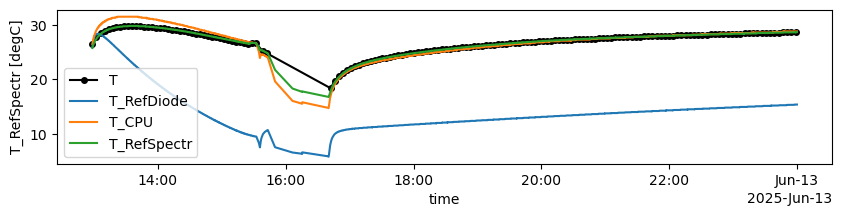

In [39]:
fig, ax = plt.subplots(1, figsize=[10,2], sharex=True)
ds['T'][::30].plot(marker='o', ms=4, c='k', ax=ax, label='T')
ds['T_RefDiode'].plot(ax=ax, label='T_RefDiode')
ds['T_CPU'].plot(ax=ax, label='T_CPU')
ds['T_RefSpectr'].plot(ax=ax, label='T_RefSpectr')

ax.legend()

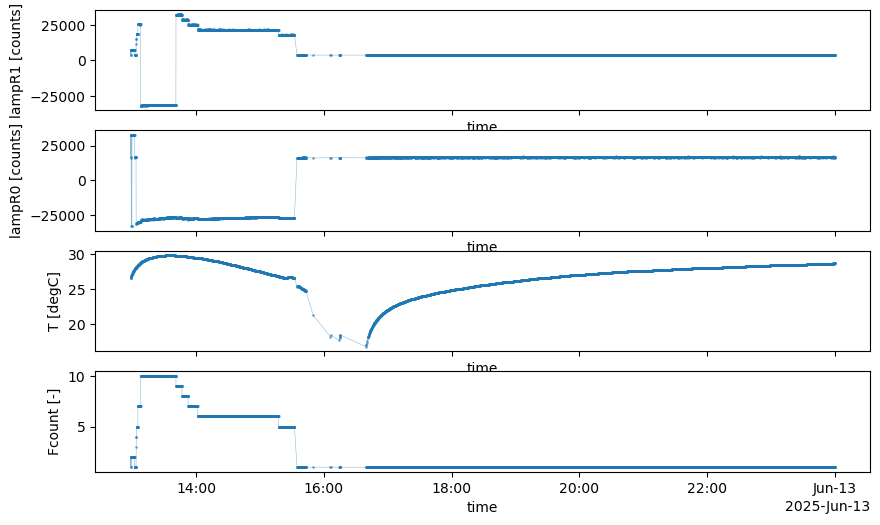

In [40]:
fig, ax = plt.subplots(4,1, figsize=[10,6], sharex=True)

ds['lampR1'].plot(lw=0.4, marker='.', ms=2, alpha=0.5, ax=ax[0], label=None)
ds['lampR0'].plot(lw=0.4, marker='.', ms=2, alpha=0.5, ax=ax[1])
ds['T'].plot(lw=0.4, marker='.', ms=2, alpha=0.5, ax=ax[2])
ds['Fcount'].plot(lw=0.4, marker='.', ms=2, alpha=0.5, ax=ax[3])

# ax[3].set_xlim([pd.to_datetime('2025-06-12 16:40'), pd.to_datetime('2025-06-12 16:45')])

In [41]:
# i2use = np.where(ds['time'] >= pd.to_datetime('2025-06-12 16:41'))
i2use = np.where(  (ds['time'] >= pd.to_datetime('2025-06-12 16:41')) &  (ds['time'] <= pd.to_datetime('2025-06-12 18:41'))  )
# i2use = np.arange(0, lR1.size, 1)
# i2use = np.arange(1250, 2000, 1)
# i2use = np.where(Fcount == 1)[0]

ds2 = ds.sel(time=slice(pd.to_datetime('2025-06-12 16:41'), pd.to_datetime('2025-06-12 23:59')))
# ds2 = ds.sel(time=slice(pd.to_datetime('2025-06-12 16:41'), pd.to_datetime('2025-06-12 22:41')))

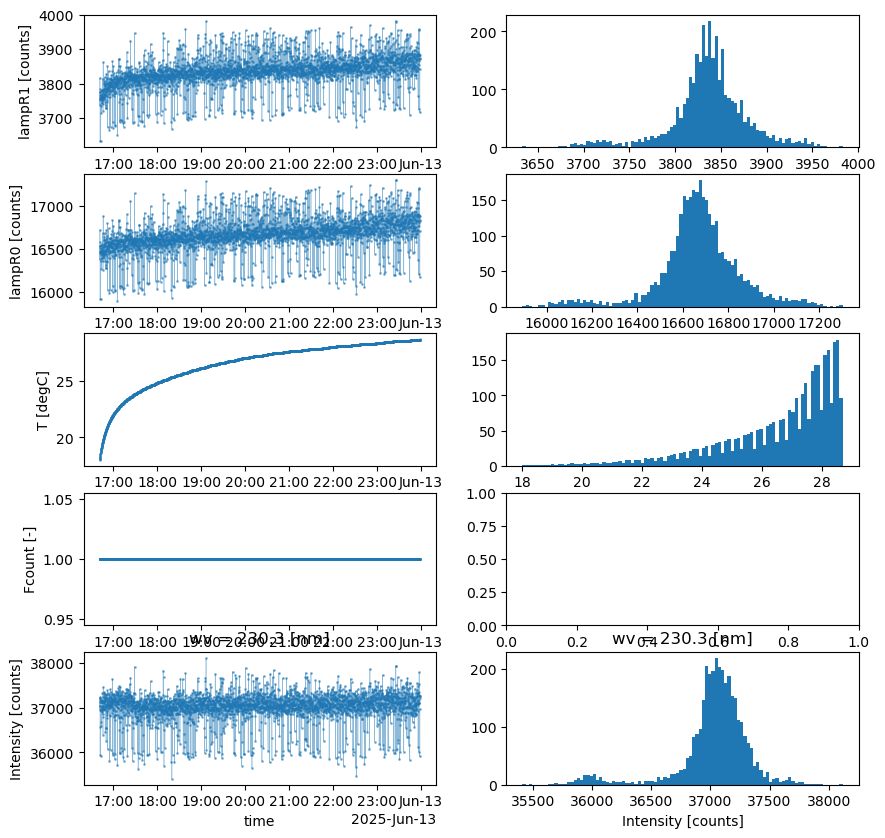

In [42]:
iwv = 50


fig, ax = plt.subplots(5,2, figsize=[10,10], sharex=False)

ds2['lampR1'].plot(lw=0.4, marker='.', ms=2, alpha=0.5, ax=ax[0,0], label=None)
ax[0,0].set_xlabel('')
ds2['lampR0'].plot(lw=0.4, marker='.', ms=2, alpha=0.5, ax=ax[1,0])
ax[1,0].set_xlabel('')
ds2['T'].plot(lw=0.4, marker='.', ms=2, alpha=0.5, ax=ax[2,0])
ax[2,0].set_xlabel('')
ds2['Fcount'].plot(lw=0.4, marker='.', ms=2, alpha=0.5, ax=ax[3,0])
ax[3,0].set_xlabel('')

ds2['Intensity'][:,iwv].plot(lw=0.4, marker='.', ms=2, alpha=0.5, ax=ax[4,0])



ds2['lampR1'].plot.hist(bins=100, ax=ax[0,1]); 
ds2['lampR0'].plot.hist(bins=100, ax=ax[1,1]);
ds2['T'].plot.hist(bins=100, ax=ax[2,1]);
ds2['Intensity'][:,iwv].plot.hist(bins=100, ax=ax[4,1]);


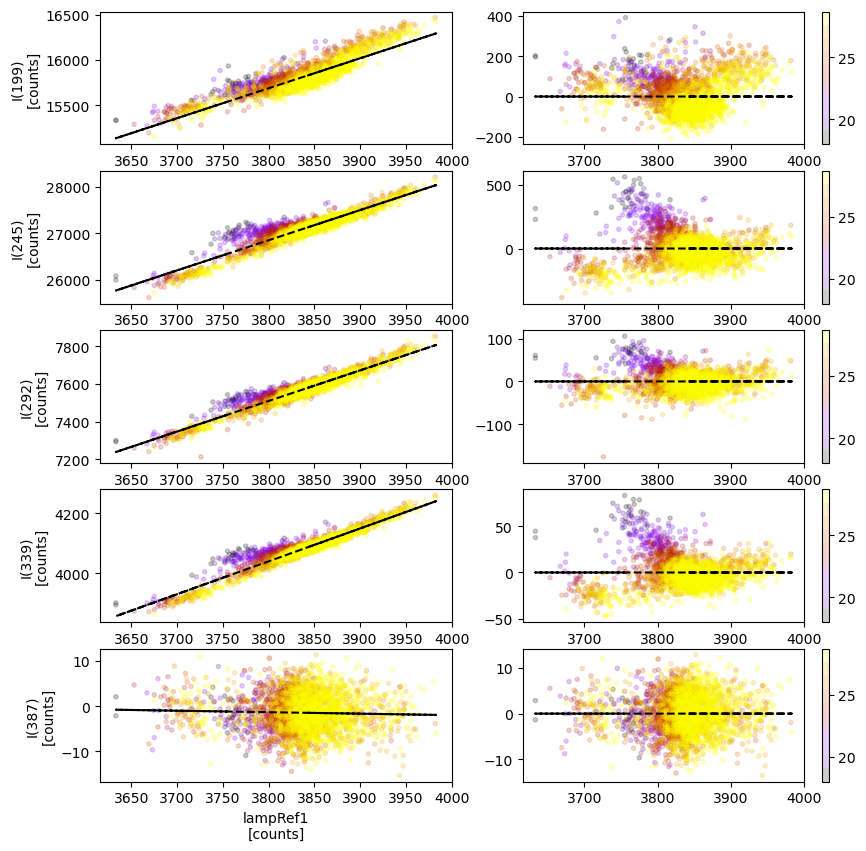

In [44]:
m = np.empty(wv.size) * np.nan
q = np.empty(wv.size) * np.nan

n_plots = 5
fig, ax = plt.subplots(n_plots, 2, figsize=[10,2*n_plots])



for ii,ip in enumerate(np.linspace(11, wv.size, n_plots).astype(int)-1):
    h = ax[ii,0].scatter(ds2['lampR1'], ds2['Intensity'][:,ip].T, c=ds2['T'], 
                         marker='.',
                         alpha=0.2, 
                         # vmin=24, vmax=25, 
                         cmap=plt.get_cmap('gnuplot', 10));
    
    ax[ii,0].set_ylabel(f'I({wv[ip]:.0f})\n[counts]')
    ax[ii,0].set_xlabel(f'lampRef1\n[counts]')

    m[ii], q[ii] = np.polyfit(ds2['lampR1'], ds2['Intensity'][:,ip], 1)
    
    pred = m[ii] * ds2['lampR1'] + q[ii]
    ax[ii,0].plot(ds2['lampR1'], pred, 'k--')
    
    h = ax[ii,1].scatter(ds2['lampR1'], ds2['Intensity'][:,ip].T - pred, c=ds2['T'],  #TrefDiode_i[iLT24], 
                         marker='.',
                         alpha=0.2, 
                         # vmin=24, vmax=25, 
                         cmap=plt.get_cmap('gnuplot', 10));
    
    ax[ii,1].plot(ds2['lampR1'], ds2['lampR1'][:]*0, 'k--')
    
    fig.colorbar(h)

In [10]:
# linear fit between lapRef to I at every wavelength
m = np.empty(wv.size) * np.nan
q = np.empty(wv.size) * np.nan
for iiw, wwv in enumerate(wv):
    m[iiw], q[iiw] = np.polyfit(ds2['lampR1'], ds2['Intensity'][:,iiw], 1)

In [45]:
io = 3000

In [53]:
T_col = 'T'
[m_lRef1, m_T] = op.cmp_R_T_corr(ds2, T_col, DIN)
[m_lRef_rob, m_T_rob, q_rob] = op.cmp_R_T_corr_robust(ds2, T_col, DIN)

Text(0, 0.5, 'm_T')

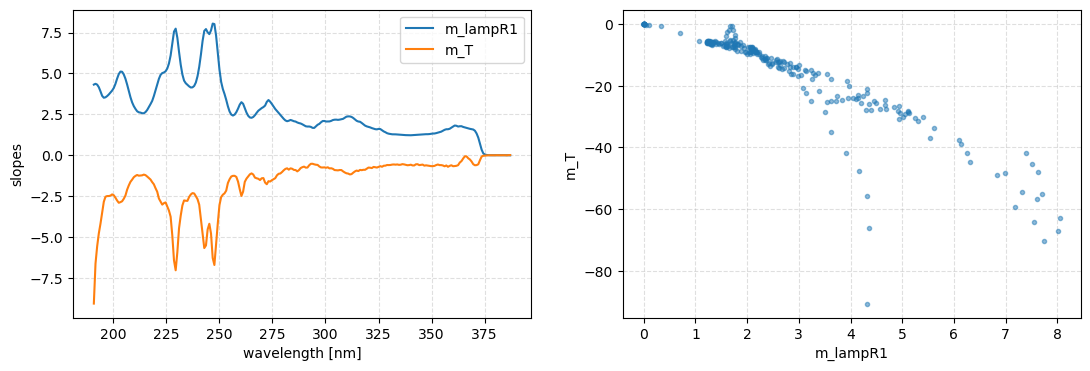

In [52]:
fig, ax = plt.subplots(1,2, figsize=[13, 4])
ax[0].plot(ds2['wv'], m_lRef1, label='m_lampR1')
ax[0].plot(ds2['wv'], m_T/10, label='m_T')
ax[0].legend()
ax[0].grid(ls='--', alpha=0.4)
ax[0].set_xlabel('wavelength [nm]')
ax[0].set_ylabel('slopes')

ax[1].plot(m_lRef1, m_T, '.', alpha=0.5)
ax[1].grid(ls='--', alpha=0.4)
ax[1].set_xlabel('m_lampR1')
ax[1].set_ylabel('m_T')


In [16]:
# apply correction

Io_Ro = ds2['Intensity'][io,:]
Io_R = np.empty(ds2['Intensity'].shape) 

dR = ds2['lampR1'].values - ds2['lampR1'][io].values
dT = ds2['T'].values - ds2['T'][io].values

Io_R_ = ds2['Intensity'][io,:].values.reshape(-1,1).T
Io_R  = ds2['Intensity'][io,:].values.reshape(-1,1).T +   m_lRef1 * dR.reshape(-1,1)   +   m_T * dT.reshape(-1,1)


T_  = ds2['Intensity'].values / Io_R_
A_  = -np.log10(np.asarray(T_))

T   = ds2['Intensity'].values / Io_R
A__ = -np.log10(np.asarray(T))


WV  = np.ones([ds2['T'].size,1]) * wv.reshape(1,-1)

/var/folders/98/ls269b9j6jq4z03kb9n9hxj40000gn/T/ipykernel_48916/2584728272.py:14: RuntimeWarning: divide by zero encountered in log10
  A_  = -np.log10(np.asarray(T_))
/var/folders/98/ls269b9j6jq4z03kb9n9hxj40000gn/T/ipykernel_48916/2584728272.py:14: RuntimeWarning: invalid value encountered in log10
  A_  = -np.log10(np.asarray(T_))
/var/folders/98/ls269b9j6jq4z03kb9n9hxj40000gn/T/ipykernel_48916/2584728272.py:17: RuntimeWarning: divide by zero encountered in log10
  A__ = -np.log10(np.asarray(T))
/var/folders/98/ls269b9j6jq4z03kb9n9hxj40000gn/T/ipykernel_48916/2584728272.py:17: RuntimeWarning: invalid value encountered in log10
  A__ = -np.log10(np.asarray(T))


Text(0, 0.5, 'absorbance [-]')

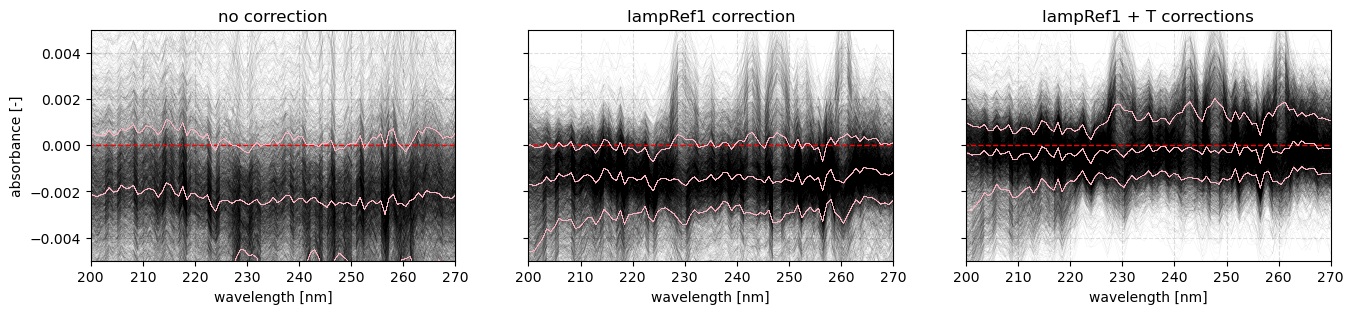

In [17]:
fig, ax = plt.subplots(1, 3, figsize=[16,3], sharex=True, sharey=True)

ax[0].plot(WV.T, A_.T, lw=.1, c='k', alpha=0.2)
ax[0].plot(wv, wv * 0, lw=1, ls='--', c='r')
ax[0].plot(WV.T, np.nanmedian(A_.T, axis=1), lw=.1, c='pink')
ax[0].plot(WV.T, np.nanpercentile(A_.T, 84, axis=1), '--', lw=.1, c='pink')
ax[0].plot(WV.T, np.nanpercentile(A_.T, 16, axis=1), '--', lw=.1, c='pink')


ax[1].plot(WV.T, A.T, lw=.1, c='k', alpha=0.2)
ax[1].plot(wv, wv * 0, lw=1, ls='--', c='r')
ax[1].plot(WV.T, np.nanmedian(A.T, axis=1), lw=.1, c='pink')
ax[1].plot(WV.T, np.nanpercentile(A.T, 84, axis=1), '--', lw=.1, c='pink')
ax[1].plot(WV.T, np.nanpercentile(A.T, 16, axis=1), '--', lw=.1, c='pink')


ax[2].plot(WV.T, A__.T, lw=.1, c='k', alpha=0.2)
ax[2].plot(wv, wv * 0, lw=1, ls='--', c='r')
ax[2].plot(WV.T, np.nanmedian(A__.T, axis=1), lw=.1, c='pink')
ax[2].plot(WV.T, np.nanpercentile(A__.T, 84, axis=1), '--', lw=.1, c='pink')
ax[2].plot(WV.T, np.nanpercentile(A__.T, 16, axis=1), '--', lw=.1, c='pink')


ax[0].set_xlim([200, 270])
ax[0].set_ylim([-0.005, 0.005])
# ax[2].set_ylim([-0.025, 0.01])

ax[0].grid(ls='--', alpha=0.4)
ax[1].grid(ls='--', alpha=0.4)
ax[2].grid(ls='--', alpha=0.4)



ax[0].set_title('no correction')
ax[1].set_title('lampRef1 correction')
ax[2].set_title('lampRef1 + T corrections')


ax[0].set_xlabel('wavelength [nm]')
ax[1].set_xlabel('wavelength [nm]')
ax[2].set_xlabel('wavelength [nm]')

ax[0].set_ylabel('absorbance [-]')

In [18]:
i200_255 = np.where((ds2['wv'] >= 200) & (ds2['wv'] <= 255))[0]

A_flat = A_[:,i200_255].flatten()
innan_ = np.where(~np.isnan(A_flat))[0]
print((np.nanpercentile(A_flat[innan_], 84) - np.nanpercentile(A_flat[innan_], 16)) / 2 / np.nanpercentile(A_flat[innan_], 50))
# print( np.nanstd(A_flat[innan_]) / np.nanmean(A_flat[innan_]))
print()

Aflat = A[:,i200_255].flatten()
innan = np.where(~np.isnan(Aflat))[0]
print((np.nanpercentile(Aflat[innan], 84) - np.nanpercentile(Aflat[innan], 16)) / 2 / np.nanpercentile(Aflat[innan], 50))
# print( np.nanstd(Aflat[innan_]) / np.nanmean(Aflat[innan_]))
print()

A__flat = A__[:,i200_255].flatten()
innan = np.where(~np.isnan(A__flat))[0]
print((np.nanpercentile(A__flat[innan], 84) - np.nanpercentile(A__flat[innan], 16)) / 2 / np.nanpercentile(A__flat[innan], 50))
# print( np.nanstd(A__flat[innan_]) / np.nanmean(A__flat[innan_]))

-1.2496988345697266

-1.066789890147257

-4.28373080197718


In [19]:
def cmp_R_T_corr_PLSR(ds):

    coeff_ = np.empty([ds['wv'].size,2]) * np.nan



    X = [   ds['lampR1'][:],
            ds['T'][:]  ]
    X = np.asarray(X).T


    for iiw,wv in enumerate(ds['wv'].values):
    
        y = ds['Intensity'].values[:,iiw]
    
        X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

        pls = PLSRegression(n_components=1)
        pls.fit(X_train, y_train)

        coeff_[iiw, :] = pls.coef_[0]
        
    return coeff_

In [20]:
coeff_ = cmp_R_T_corr_PLSR(ds2)

Text(0, 0.5, 'coeff_[1]')

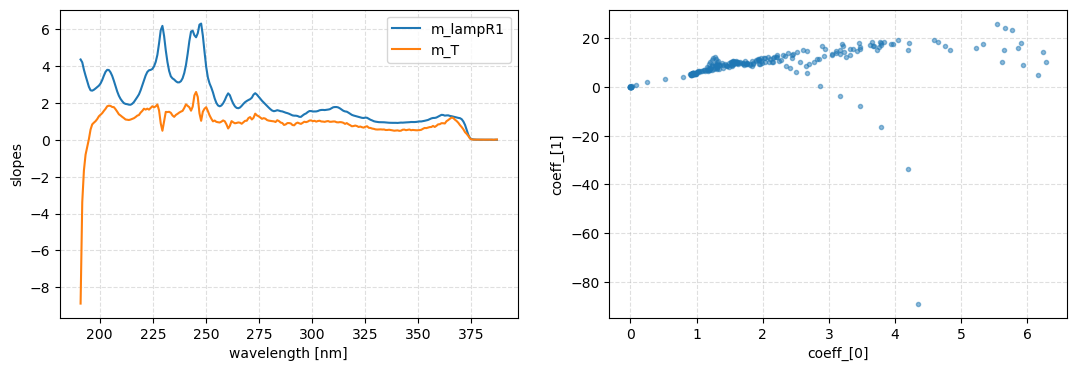

In [21]:
fig, ax = plt.subplots(1,2, figsize=[13, 4])
ax[0].plot(ds2['wv'], coeff_[:,0], label='m_lampR1')
ax[0].plot(ds2['wv'], coeff_[:,1]/10, label='m_T')
ax[0].legend()
ax[0].grid(ls='--', alpha=0.4)
ax[0].set_xlabel('wavelength [nm]')
ax[0].set_ylabel('slopes')

ax[1].plot( coeff_[:,0],  coeff_[:,1], '.', alpha=0.5)
ax[1].grid(ls='--', alpha=0.4)
ax[1].set_xlabel('coeff_[0]')
ax[1].set_ylabel('coeff_[1]')

In [22]:
# apply correction

Io_Ro = ds2['Intensity'][io,:]
Io_R = np.empty(ds2['Intensity'].shape) 

dR = ds2['lampR1'].values - ds2['lampR1'][io].values
dT = ds2['T'].values - ds2['T'][io].values

Io_R  = ds2['Intensity'][io,:].values.reshape(-1,1).T +   coeff_[:,0] * dR.reshape(-1,1)   +   coeff_[:,1] * dT.reshape(-1,1)

T   = ds2['Intensity'].values / Io_R
A___ = -np.log10(np.asarray(T))






/var/folders/98/ls269b9j6jq4z03kb9n9hxj40000gn/T/ipykernel_48916/3105560752.py:12: RuntimeWarning: divide by zero encountered in log10
  A___ = -np.log10(np.asarray(T))
/var/folders/98/ls269b9j6jq4z03kb9n9hxj40000gn/T/ipykernel_48916/3105560752.py:12: RuntimeWarning: invalid value encountered in log10
  A___ = -np.log10(np.asarray(T))


In [23]:
i200_255 = np.where((ds2['wv'] >= 200) & (ds2['wv'] <= 255))[0]

A_flat = A_[:,i200_255].flatten()
innan_ = np.where(~np.isnan(A_flat))[0]
print((np.nanpercentile(A_flat[innan_], 84) - np.nanpercentile(A_flat[innan_], 16)) / 2 / np.nanpercentile(A_flat[innan_], 50))
# print( np.nanstd(A_flat[innan_]) / np.nanmean(A_flat[innan_]))
print()

Aflat = A[:,i200_255].flatten()
innan = np.where(~np.isnan(Aflat))[0]
print((np.nanpercentile(Aflat[innan], 84) - np.nanpercentile(Aflat[innan], 16)) / 2 / np.nanpercentile(Aflat[innan], 50))
# print( np.nanstd(Aflat[innan_]) / np.nanmean(Aflat[innan_]))
print()

A__flat = A__[:,i200_255].flatten()
innan = np.where(~np.isnan(A__flat))[0]
print((np.nanpercentile(A__flat[innan], 84) - np.nanpercentile(A__flat[innan], 16)) / 2 / np.nanpercentile(A__flat[innan], 50))
# print( np.nanstd(A__flat[innan_]) / np.nanmean(A__flat[innan_]))
print()

A___flat = A___[:,i200_255].flatten()
innan = np.where(~np.isnan(A___flat))[0]
print((np.nanpercentile(A___flat[innan], 84) - np.nanpercentile(A___flat[innan], 16)) / 2 / np.nanpercentile(A___flat[innan], 50))
# print( np.nanstd(A__flat[innan_]) / np.nanmean(A__flat[innan_]))

-1.2496988345697266

-1.066789890147257

-4.28373080197718

-0.896949563224168


Text(0, 0.5, 'absorbance [-]')

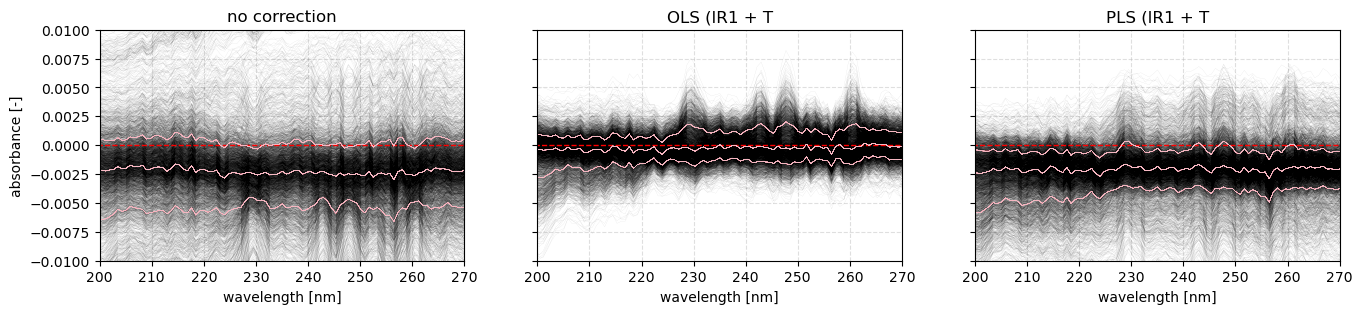

In [24]:
fig, ax = plt.subplots(1, 3, figsize=[16,3], sharex=True, sharey=True)

ax[0].plot(WV.T, A_.T, lw=.1, c='k', alpha=0.2)
ax[0].plot(wv, wv * 0, lw=1, ls='--', c='r')
ax[0].plot(WV.T, np.nanmedian(A_.T, axis=1), lw=.1, c='pink')
ax[0].plot(WV.T, np.nanpercentile(A_.T, 84, axis=1), '--', lw=.1, c='pink')
ax[0].plot(WV.T, np.nanpercentile(A_.T, 16, axis=1), '--', lw=.1, c='pink')


ax[1].plot(WV.T, A__.T, lw=.1, c='k', alpha=0.2)
ax[1].plot(wv, wv * 0, lw=1, ls='--', c='r')
ax[1].plot(WV.T, np.nanmedian(A__.T, axis=1), lw=.1, c='pink')
ax[1].plot(WV.T, np.nanpercentile(A__.T, 84, axis=1), '--', lw=.1, c='pink')
ax[1].plot(WV.T, np.nanpercentile(A__.T, 16, axis=1), '--', lw=.1, c='pink')


ax[2].plot(WV.T, A___.T, lw=.1, c='k', alpha=0.2)
ax[2].plot(wv, wv * 0, lw=1, ls='--', c='r')
ax[2].plot(WV.T, np.nanmedian(A___.T, axis=1), lw=.1, c='pink')
ax[2].plot(WV.T, np.nanpercentile(A___.T, 84, axis=1), '--', lw=.1, c='pink')
ax[2].plot(WV.T, np.nanpercentile(A___.T, 16, axis=1), '--', lw=.1, c='pink')


ax[0].set_xlim([200, 270])
ax[0].set_ylim([-0.01, 0.01])
# ax[2].set_ylim([-0.025, 0.01])

ax[0].grid(ls='--', alpha=0.4)
ax[1].grid(ls='--', alpha=0.4)
ax[2].grid(ls='--', alpha=0.4)



ax[0].set_title('no correction')
ax[1].set_title('OLS (lR1 + T')
ax[2].set_title('PLS (lR1 + T')


ax[0].set_xlabel('wavelength [nm]')
ax[1].set_xlabel('wavelength [nm]')
ax[2].set_xlabel('wavelength [nm]')

ax[0].set_ylabel('absorbance [-]')

# To do
## - collect more data at lower T
## - check what the other Ts were doing during what the other Ts were doing during experiment
## - there is a bias in the OLS estimate (at $\lambda >230$ nm) that disappears in PLS: why?
## - what happens at $\lambda < 230$ nm for PLS? why is the noise increasing? Are the data not good enough? 